In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('C:/Users/yendi/Documents/Collegeinabunker/Project/hotel_bookings/archive (1)/hotel_bookings.csv')
print(df.head())
print(df.columns.tolist())
print(df.shape)

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [5]:
print(df.isnull().sum())
print(df['is_canceled'].value_counts(normalize=True))
print(df['hotel'].value_counts())
print(df['adr'].describe())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [6]:
# Data cleaning
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

# Remove ADR outliers (negative and extreme values)
df = df[(df['adr'] >= 0) & (df['adr'] <= 1000)]

# Verify
print(f"Clean dataset shape: {df.shape}")
print(f"ADR range: ${df['adr'].min():.2f} - ${df['adr'].max():.2f}")

# Cancellation by hotel type
print("\nCancellation rate by hotel:")
print(df.groupby('hotel')['is_canceled'].mean().round(3))

Clean dataset shape: (119388, 32)
ADR range: $0.00 - $510.00

Cancellation rate by hotel:
hotel
City Hotel      0.417
Resort Hotel    0.278
Name: is_canceled, dtype: float64


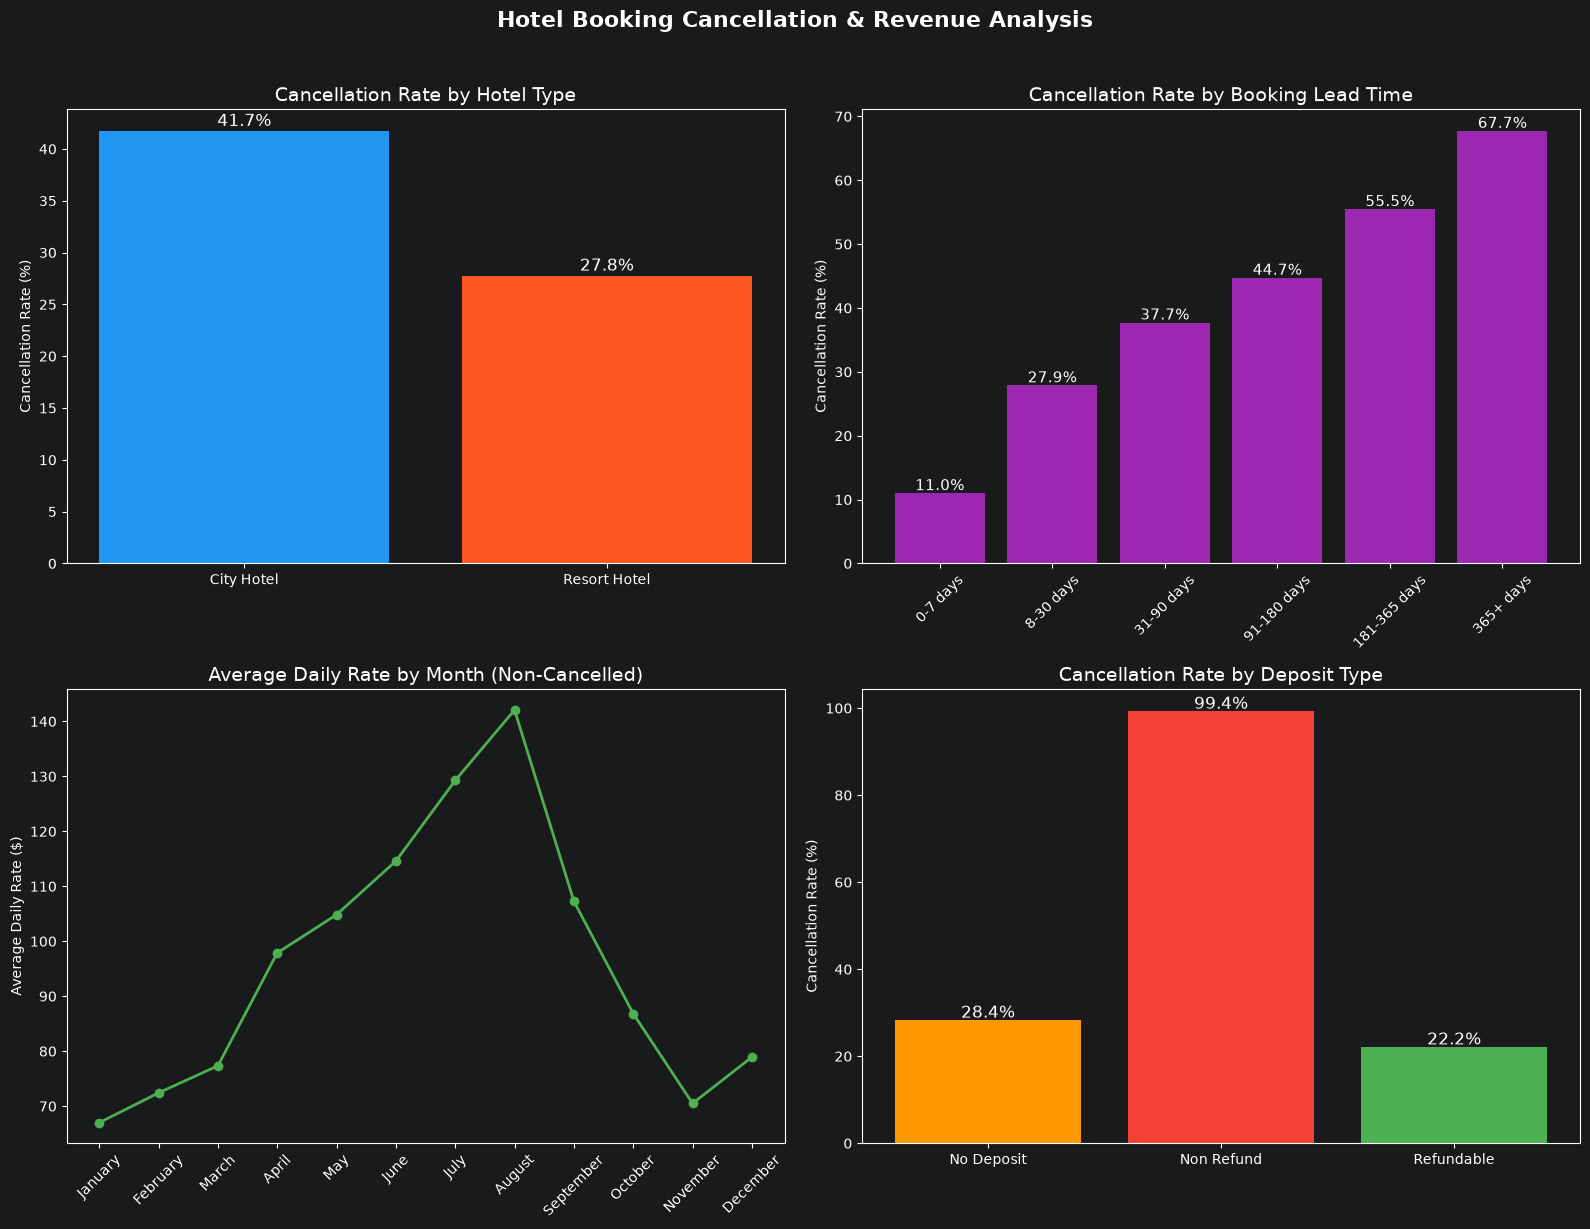

In [7]:
# arrival date for time series
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str)
)

# plot 1: cancellation rate by hotel type
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
axes[0,0].bar(cancel_by_hotel.index, cancel_by_hotel.values,
              color=['#2196F3', '#FF5722'])
axes[0,0].set_title('Cancellation Rate by Hotel Type', fontsize=14)
axes[0,0].set_ylabel('Cancellation Rate (%)')
for i, v in enumerate(cancel_by_hotel.values):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

# plot 2: cancellation by lead time buckets
df['lead_time_bucket'] = pd.cut(df['lead_time'],
    bins=[0, 7, 30, 90, 180, 365, 700],
    labels=['0-7 days', '8-30 days', '31-90 days',
            '91-180 days', '181-365 days', '365+ days'])
cancel_by_lead = df.groupby('lead_time_bucket')['is_canceled'].mean() * 100
axes[0,1].bar(cancel_by_lead.index, cancel_by_lead.values, color='#9C27B0')
axes[0,1].set_title('Cancellation Rate by Booking Lead Time', fontsize=14)
axes[0,1].set_ylabel('Cancellation Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(cancel_by_lead.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

# plot 3: ADR by month
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'],
    categories=['January','February','March','April','May','June',
                'July','August','September','October','November','December'],
    ordered=True)
adr_by_month = df[df['is_canceled']==0].groupby(
    'arrival_date_month')['adr'].mean()
axes[1,0].plot(adr_by_month.index, adr_by_month.values,
               marker='o', color='#4CAF50', linewidth=2)
axes[1,0].set_title('Average Daily Rate by Month (Non-Cancelled)', fontsize=14)
axes[1,0].set_ylabel('Average Daily Rate ($)')
axes[1,0].tick_params(axis='x', rotation=45)

# plot 4: cancellation by deposit type
cancel_by_deposit = df.groupby('deposit_type')['is_canceled'].mean() * 100
axes[1,1].bar(cancel_by_deposit.index, cancel_by_deposit.values,
              color=['#FF9800', '#F44336', '#4CAF50'])
axes[1,1].set_title('Cancellation Rate by Deposit Type', fontsize=14)
axes[1,1].set_ylabel('Cancellation Rate (%)')
for i, v in enumerate(cancel_by_deposit.values):
    axes[1,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

plt.suptitle('Hotel Booking Cancellation & Revenue Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

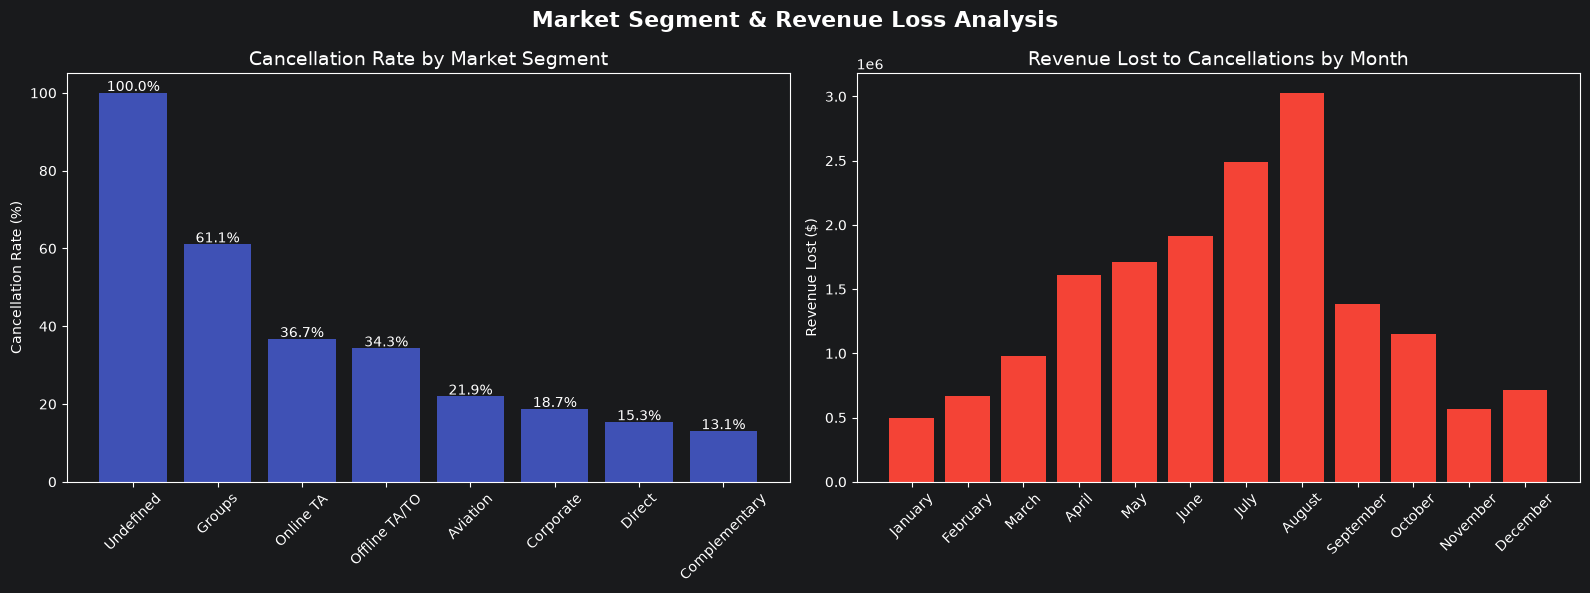

Total revenue lost to cancellations: $16,721,837.12


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plot 5: cancellation by market segment
cancel_by_segment = df.groupby('market_segment')['is_canceled'].mean() * 100
cancel_by_segment = cancel_by_segment.sort_values(ascending=False)
axes[0].bar(cancel_by_segment.index, cancel_by_segment.values, color='#3F51B5')
axes[0].set_title('Cancellation Rate by Market Segment', fontsize=14)
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(cancel_by_segment.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

# plot 6: revenue lost to cancellations by month
df['revenue'] = df['adr'] * (df['stays_in_weekend_nights'] +
                              df['stays_in_week_nights'])
revenue_lost = df[df['is_canceled']==1].groupby(
    'arrival_date_month')['revenue'].sum()
axes[1].bar(revenue_lost.index, revenue_lost.values, color='#F44336')
axes[1].set_title('Revenue Lost to Cancellations by Month', fontsize=14)
axes[1].set_ylabel('Revenue Lost ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Market Segment & Revenue Loss Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# total revenue lost
total_lost = df[df['is_canceled']==1]['revenue'].sum()
print(f"Total revenue lost to cancellations: ${total_lost:,.2f}")

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

# features to show
features = [
    'hotel', 'lead_time', 'arrival_date_month',
    'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'market_segment', 'distribution_channel',
    'is_repeated_guest', 'previous_cancellations',
    'previous_bookings_not_canceled', 'deposit_type',
    'customer_type', 'adr', 'total_of_special_requests',
    'days_in_waiting_list', 'booking_changes'
]

df_model = df[features + ['is_canceled']].copy()

# encode categorical variables
le = LabelEncoder()
categorical_cols = ['hotel', 'arrival_date_month', 'market_segment',
                    'distribution_channel', 'deposit_type', 'customer_type']

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# split data
X = df_model.drop('is_canceled', axis=1)
y = df_model['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# evaluate
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"\nModel Accuracy: {rf_model.score(X_test, y_test):.3f}")

# feature importance
importance_df = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89     14983
           1       0.85      0.74      0.79      8895

    accuracy                           0.85     23878
   macro avg       0.85      0.83      0.84     23878
weighted avg       0.85      0.85      0.85     23878


Model Accuracy: 0.855

Top 10 Most Important Features:
                      feature  importance
1                   lead_time    0.227143
13                        adr    0.178643
11               deposit_type    0.153052
2          arrival_date_month    0.070603
14  total_of_special_requests    0.066357
4        stays_in_week_nights    0.058416
6              market_segment    0.056081
9      previous_cancellations    0.044317
3     stays_in_weekend_nights    0.033786
12              customer_type    0.029410


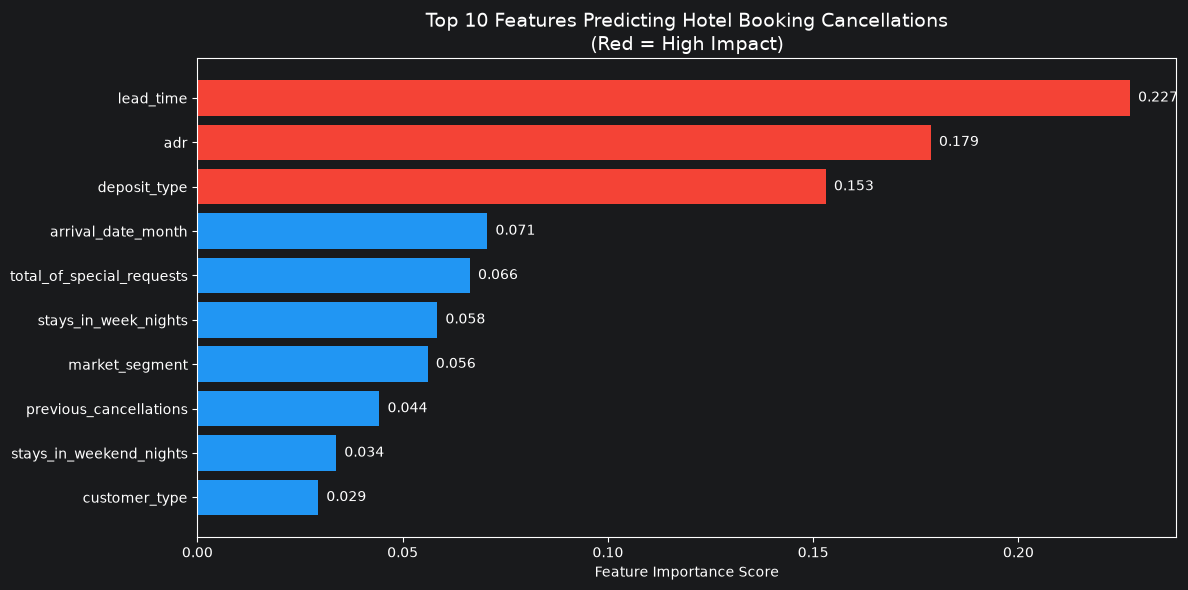

In [10]:
# feature of importance plot
plt.figure(figsize=(12, 6))
colors = ['#F44336' if x > 0.1 else '#2196F3'
          for x in importance_df.head(10)['importance']]
plt.barh(importance_df.head(10)['feature'],
         importance_df.head(10)['importance'],
         color=colors)
plt.xlabel('Feature Importance Score')
plt.title('Top 10 Features Predicting Hotel Booking Cancellations\n(Red = High Impact)',
          fontsize=14)
plt.gca().invert_yaxis()
for i, v in enumerate(importance_df.head(10)['importance']):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
# export data with prediction probabilities for Tableau
df_export = df.copy()

# add cancellation probability from our model
df_model_full = df[features].copy()
for col in categorical_cols:
    df_model_full[col] = le.fit_transform(df_model_full[col].astype(str))

df_export['cancellation_probability'] = rf_model.predict_proba(
    df_model_full)[:, 1]

# revenue column
df_export['revenue'] = df_export['adr'] * (
    df_export['stays_in_weekend_nights'] +
    df_export['stays_in_week_nights'])

# risk category
df_export['risk_category'] = pd.cut(
    df_export['cancellation_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'])

df_export.to_csv('C:/Users/yendi/Documents/Collegeinabunker/Project/hotel_bookings_analyzed.csv', index=False)
print("Export successful!")
print(f"Columns added: cancellation_probability, revenue, risk_category")
print(df_export['risk_category'].value_counts())

Export successful!
Columns added: cancellation_probability, revenue, risk_category
risk_category
Low Risk       56211
High Risk      41380
Medium Risk     5563
Name: count, dtype: int64


In [12]:
# check for nulls in 'lead_time_bucket'
print(df_export['lead_time_bucket'].isna().sum())

# recreate the buckets properly
df_export['lead_time_bucket'] = pd.cut(
    df_export['lead_time'],
    bins=[-1, 7, 30, 90, 180, 365, 700],
    labels=['1. 0-7 days', '2. 8-30 days', '3. 31-90 days',
            '4. 91-180 days', '5. 181-365 days', '6. 365+ days'])

# verify no nulls
print(df_export['lead_time_bucket'].isna().sum())
print(df_export['lead_time_bucket'].value_counts())

df_export.to_csv('hotel_bookings_analyzed.csv', index=False)
print("Re-exported successfully!")

6347
2
lead_time_bucket
3. 31-90 days      29552
4. 91-180 days     26439
5. 181-365 days    21543
1. 0-7 days        19746
2. 8-30 days       18960
6. 365+ days        3146
Name: count, dtype: int64
Re-exported successfully!


In [13]:
importance_data = pd.DataFrame({
    'Feature': ['Lead Time', 'ADR', 'Deposit Type',
                'Arrival Month', 'Special Requests',
                'Week Nights', 'Market Segment',
                'Previous Cancellations',
                'Weekend Nights', 'Customer Type'],
    'Importance': [0.227, 0.179, 0.153, 0.071,
                   0.066, 0.058, 0.056, 0.044,
                   0.034, 0.029]
})

importance_data.to_csv('feature_importance.csv', index=False)
print("done")

Exported!
